# Матрица корреляций (Титаник)
Анализируем, какие признаки связаны с выживаемостью пассажиров и строим матрицу корреляции

## 1. Загрузка данных

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 80
df = pd.read_csv('titanic.csv')
print(f'Строк: {len(df)}, столбцов: {df.shape[1]}')
df.head()

Строк: 891, столбцов: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# Смотрим пропущенные значения, ведь без этого корреляция не посчитается
print('Пропущенные значения:')
print(df.isnull().sum())

Пропущенные значения:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 2. Предобработка данных

Матрица корреляций работает **только с числами**. Поэтому нужно:
- удалить текстовые столбцы, которые нельзя осмысленно закодировать
- закодировать пол и порт цифрами
- заполнить пропуски (строки с NaN не участвуют в расчёте)

In [10]:
# 1. Удаляем столбцы, которые не несут полезной числовой информации
df = df.drop(columns=['Name', 'Ticket', 'Cabin'], errors='ignore')

# 2. Кодируем признаки числами 
df['Sex']      = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 3. Заполняем пропуски: возраст — медианой, порт — нулём
df['Age']      = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(0)

# 4. Дополнительный признак: размер семьи
df['FamilySize'] = df['SibSp'] + df['Parch']

print('Типы после предобработки:')
print(df.dtypes)

Типы после предобработки:
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked       float64
FamilySize       int64
dtype: object


## 3. Матрица корреляций

Значение от **-1 до +1**:
- `+1` -> прямая связь (один растёт, значит другой тоже)
- `-1` -> обратная связь
- `0` -> нет линейной связи

In [11]:
corr_m = df.corr()

print('Корреляция с выживаемостью:')
print(corr_m['Survived'].sort_values(ascending=False).to_string())

Корреляция с выживаемостью:
Survived       1.000000
Sex            0.543351
Fare           0.257307
Embarked       0.106811
Parch          0.081629
FamilySize     0.016639
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481


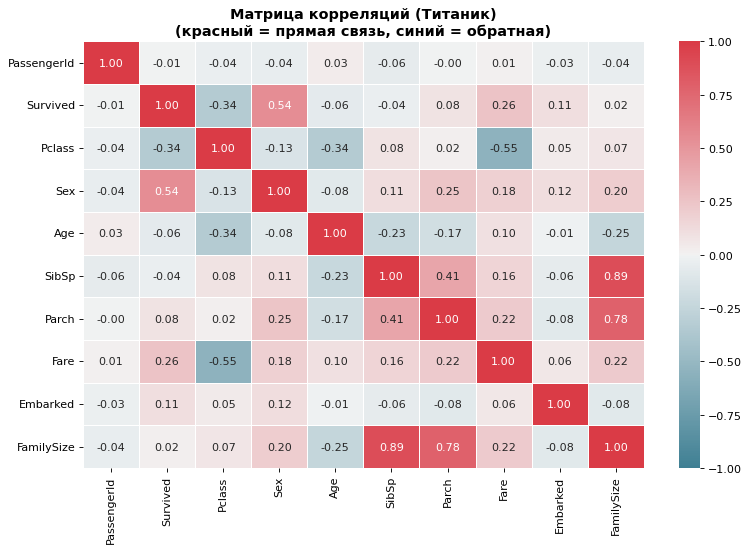

In [12]:
plt.figure(figsize=(10, 7))

cmap = sns.diverging_palette(220, 10, as_cmap=True)  # синий = отрицательная, красный = положительная

sns.heatmap(
    corr_m,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Матрица корреляций (Титаник)\n(красный = прямая связь, синий = обратная)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('titanic_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Визуальный анализ: информация в графиках

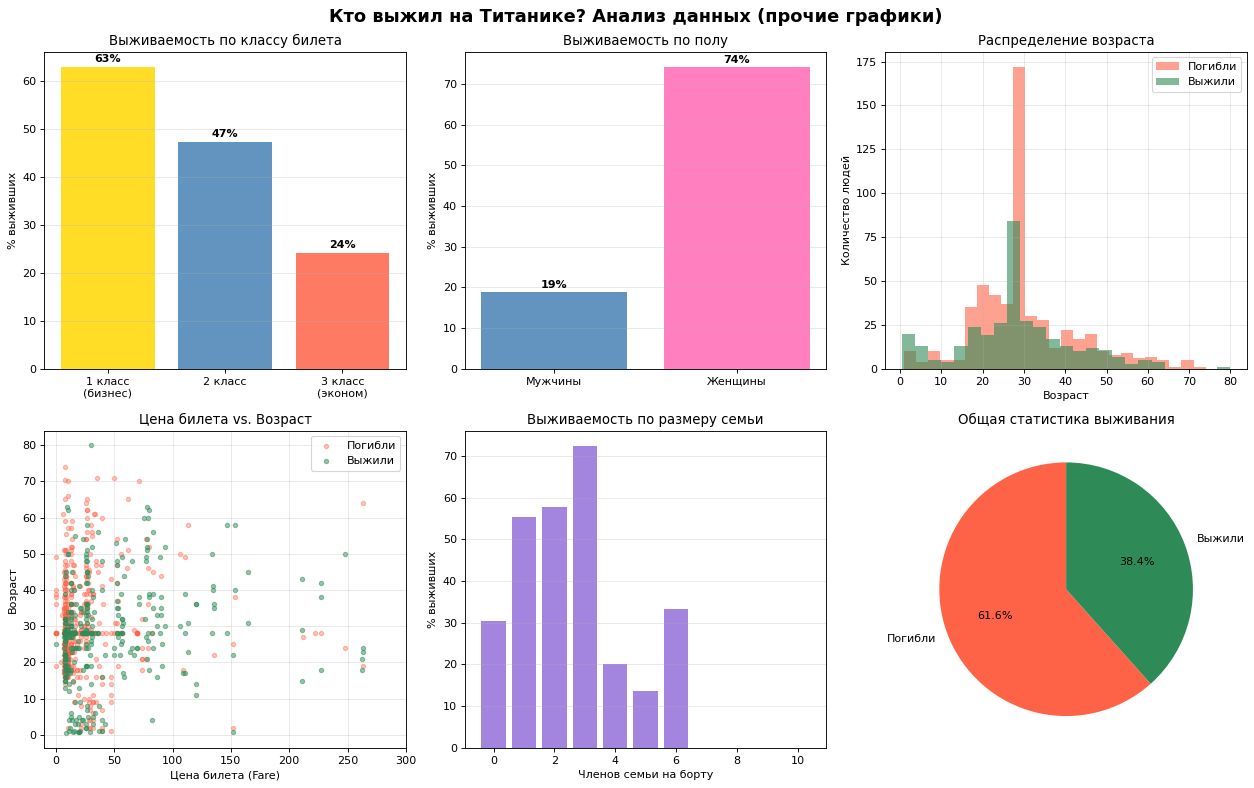

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Кто выжил на Титанике? Анализ данных (прочие графики)', fontsize=16, fontweight='bold')

# 1) Выживаемость по полу
surv_sex = df.groupby('Sex')['Survived'].mean() * 100
label_map = {0: 'Мужчины', 1: 'Женщины'}
labels = [label_map.get(i, str(i)) for i in surv_sex.index]
colors = ['steelblue' if i == 0 else 'hotpink' for i in surv_sex.index]
axes[0, 1].bar(labels, surv_sex.values, color=colors, alpha=0.85)
for ax_bar, val in zip(axes[0, 1].patches, surv_sex.values):
    axes[0, 1].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height() + 1,
                    f'{val:.0f}%', ha='center', fontweight='bold')
axes[0, 1].set_title('Выживаемость по полу')
axes[0, 1].set_ylabel('% выживших')
axes[0, 1].grid(True, alpha=0.3, axis='y')


# 2) Выживаемость по классу
surv_class = df.groupby('Pclass')['Survived'].mean() * 100
axes[0, 0].bar(['1 класс\n(бизнес)', '2 класс', '3 класс\n(эконом)'],
               surv_class.values, color=['gold', 'steelblue', 'tomato'], alpha=0.85)
for ax_bar, val in zip(axes[0, 0].patches, surv_class.values):
    axes[0, 0].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height() + 1,
                    f'{val:.0f}%', ha='center', fontweight='bold')
axes[0, 0].set_title('Выживаемость по классу билета')
axes[0, 0].set_ylabel('% выживших')
axes[0, 0].grid(True, alpha=0.3, axis='y')


# 3) Распределение возраста
axes[0, 2].hist(df[df['Survived']==0]['Age'], bins=25, alpha=0.6, color='tomato', label='Погибли')
axes[0, 2].hist(df[df['Survived']==1]['Age'], bins=25, alpha=0.6, color='seagreen', label='Выжили')
axes[0, 2].set_title('Распределение возраста')
axes[0, 2].set_xlabel('Возраст')
axes[0, 2].set_ylabel('Количество людей')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4) Выживаемость по размеру семьи
surv_fam = df.groupby('FamilySize')['Survived'].mean() * 100
axes[1, 1].bar(surv_fam.index, surv_fam.values, color='mediumpurple', alpha=0.85)
axes[1, 1].set_title('Выживаемость по размеру семьи')
axes[1, 1].set_xlabel('Членов семьи на борту')
axes[1, 1].set_ylabel('% выживших')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 5) Цена билета и Возраст
axes[1, 0].scatter(df[df['Survived']==0]['Fare'], df[df['Survived']==0]['Age'],
                   alpha=0.4, color='tomato', label='Погибли', s=15)
axes[1, 0].scatter(df[df['Survived']==1]['Fare'], df[df['Survived']==1]['Age'],
                   alpha=0.5, color='seagreen', label='Выжили', s=15)
axes[1, 0].set_title('Цена билета vs. Возраст')
axes[1, 0].set_xlabel('Цена билета (Fare)')
axes[1, 0].set_ylabel('Возраст')
axes[1, 0].set_xlim(-10, 300)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)


# 6) Общая статистика
total = df['Survived'].value_counts()
axes[1, 2].pie(total.values, labels=['Погибли', 'Выжили'],
               autopct='%1.1f%%', colors=['tomato', 'seagreen'], startangle=90)
axes[1, 2].set_title('Общая статистика выживания')

plt.tight_layout()
plt.savefig('titanic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Выводы

| Признак | Корреляция с выжившими | Вывод |
|---|---|---|
| **Sex** | +0.54 | Женщины выживали значительно чаще (принцип «женщины и дети — первыми») |
| **Pclass** | −0.34 | Чем выше класс (1-й самый лучший), тем больше шансов выжить |
| **Fare** | +0.26 | Дорогой билет коррелирует с выживанием (и с классом) |
| **Age** | −0.06 | Почти нет линейной зависимости |
| **PassengerId** | −0.01 | Нет смысловой связи: просто порядковый номер |

> **Главный вывод:** пол — самый сильный фактор. Далее класс и цена билета, которые отражают социальный статус пассажира.